In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns
import numpy as np

import torch

import sys
import os
parent_dir = os.path.abspath(os.path.join(os.path.dirname('utils.py'), ".."))
sys.path.append(parent_dir)
import utils as ut
import fc

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
cwd = Path.cwd()
cutout_dir = cwd.parent / 'data' / 'cutouts'
table_dir = cwd.parent / 'data' / 'tables'
model_dir = cwd.parent / 'models'

In [5]:
tables = table_dir.rglob('*')
df = pd.concat((pd.read_csv(t) for t in tables), ignore_index=True)

ceers_flux = df.filter(regex='^FLUX_')
ceers_err = df.filter(regex='^FLUXERR_')
primer_flux = df.filter(regex='^f_f') / 10
primer_err = df.filter(regex='^e_f') / 10

df.drop((list(ceers_flux.columns) + list(primer_flux.columns)
         + list(ceers_err.columns) + list(primer_err.columns)),
         inplace=True, axis=1)

ceers_flux.rename(columns=lambda x: x.replace('FLUX_', 'F'), inplace=True)
primer_flux.rename(columns=lambda x: x.replace('f_f', 'F')[:-1], inplace=True)
ceers_err.rename(columns=lambda x: x.replace('FLUXERR_', 'E'), inplace=True)
primer_err.rename(columns=lambda x: x.replace('e_f', 'E')[:-1], inplace=True)

combined_flux = ceers_flux.combine_first(primer_flux)
combined_err = ceers_err.combine_first(primer_err)

combined_flux = combined_flux.mask(combined_flux <= 0.1, np.nan)
combined_err = combined_err.mask(combined_err <= 0.1, np.nan)

df = pd.concat([df, np.log10(combined_flux), np.log10(combined_err)], axis=1)

In [6]:
in_features = list(combined_flux.columns) + ['beta', 'Av', 'dec']
out_feature = 'flag'

bad_av = df['Av'] == -99
bad_beta = df['beta'] == -99
df = df[~bad_beta | ~bad_av]

In [7]:
list(df.columns)

['ID',
 'CATID',
 'RA',
 'DEC',
 'FIELD',
 'KRON_RADIUS',
 'A_IMAGE',
 'B_IMAGE',
 'THETA_IMAGE',
 'RH_F200W',
 'FWHM_F200W',
 'c_Hmag',
 'c_zbest',
 'c_zspec',
 'c_mass',
 'c_sfrtot',
 'c_U',
 'c_V',
 'c_J',
 'c_gf_phy_re_h',
 'c_zhu_sig1',
 'c_ACS_F606W_FLUX',
 'c_ACS_F606W_FLUXERR',
 'c_ACS_F814W_FLUX',
 'c_ACS_F814W_FLUXERR',
 'c_WFC3_F140W_FLUX',
 'c_WFC3_F140W_FLUXERR',
 'c_WFC3_F125W_FLUX',
 'c_WFC3_F125W_FLUXERR',
 'c_WFC3_F160W_FLUX',
 'c_WFC3_F160W_FLUXERR',
 'sepmos',
 'Kmag',
 'm_zspec',
 'm_zspec_zqual',
 'm_zspec_use',
 'id_2',
 'ra',
 'dec',
 'z_spec',
 'nusefilt',
 'z_ml',
 'z_ml_chi2',
 'z_ml_risk',
 'z_phot',
 'z_phot_chi2',
 'z_phot_risk',
 'z_min_risk',
 'min_risk',
 'z_raw_chi2',
 'raw_chi2',
 'z025',
 'z160',
 'z500',
 'z840',
 'z975',
 'restU',
 'restU_err',
 'restB',
 'restB_err',
 'restV',
 'restV_err',
 'restJ',
 'restJ_err',
 'dL',
 'Lv',
 'mass',
 'sfr',
 'LIR',
 'energy_abs',
 'Av',
 'lw_age_V',
 'MLv',
 'UV',
 'VJ',
 'lmass',
 'ZA_finkelstein',
 'ZPEAK_fin

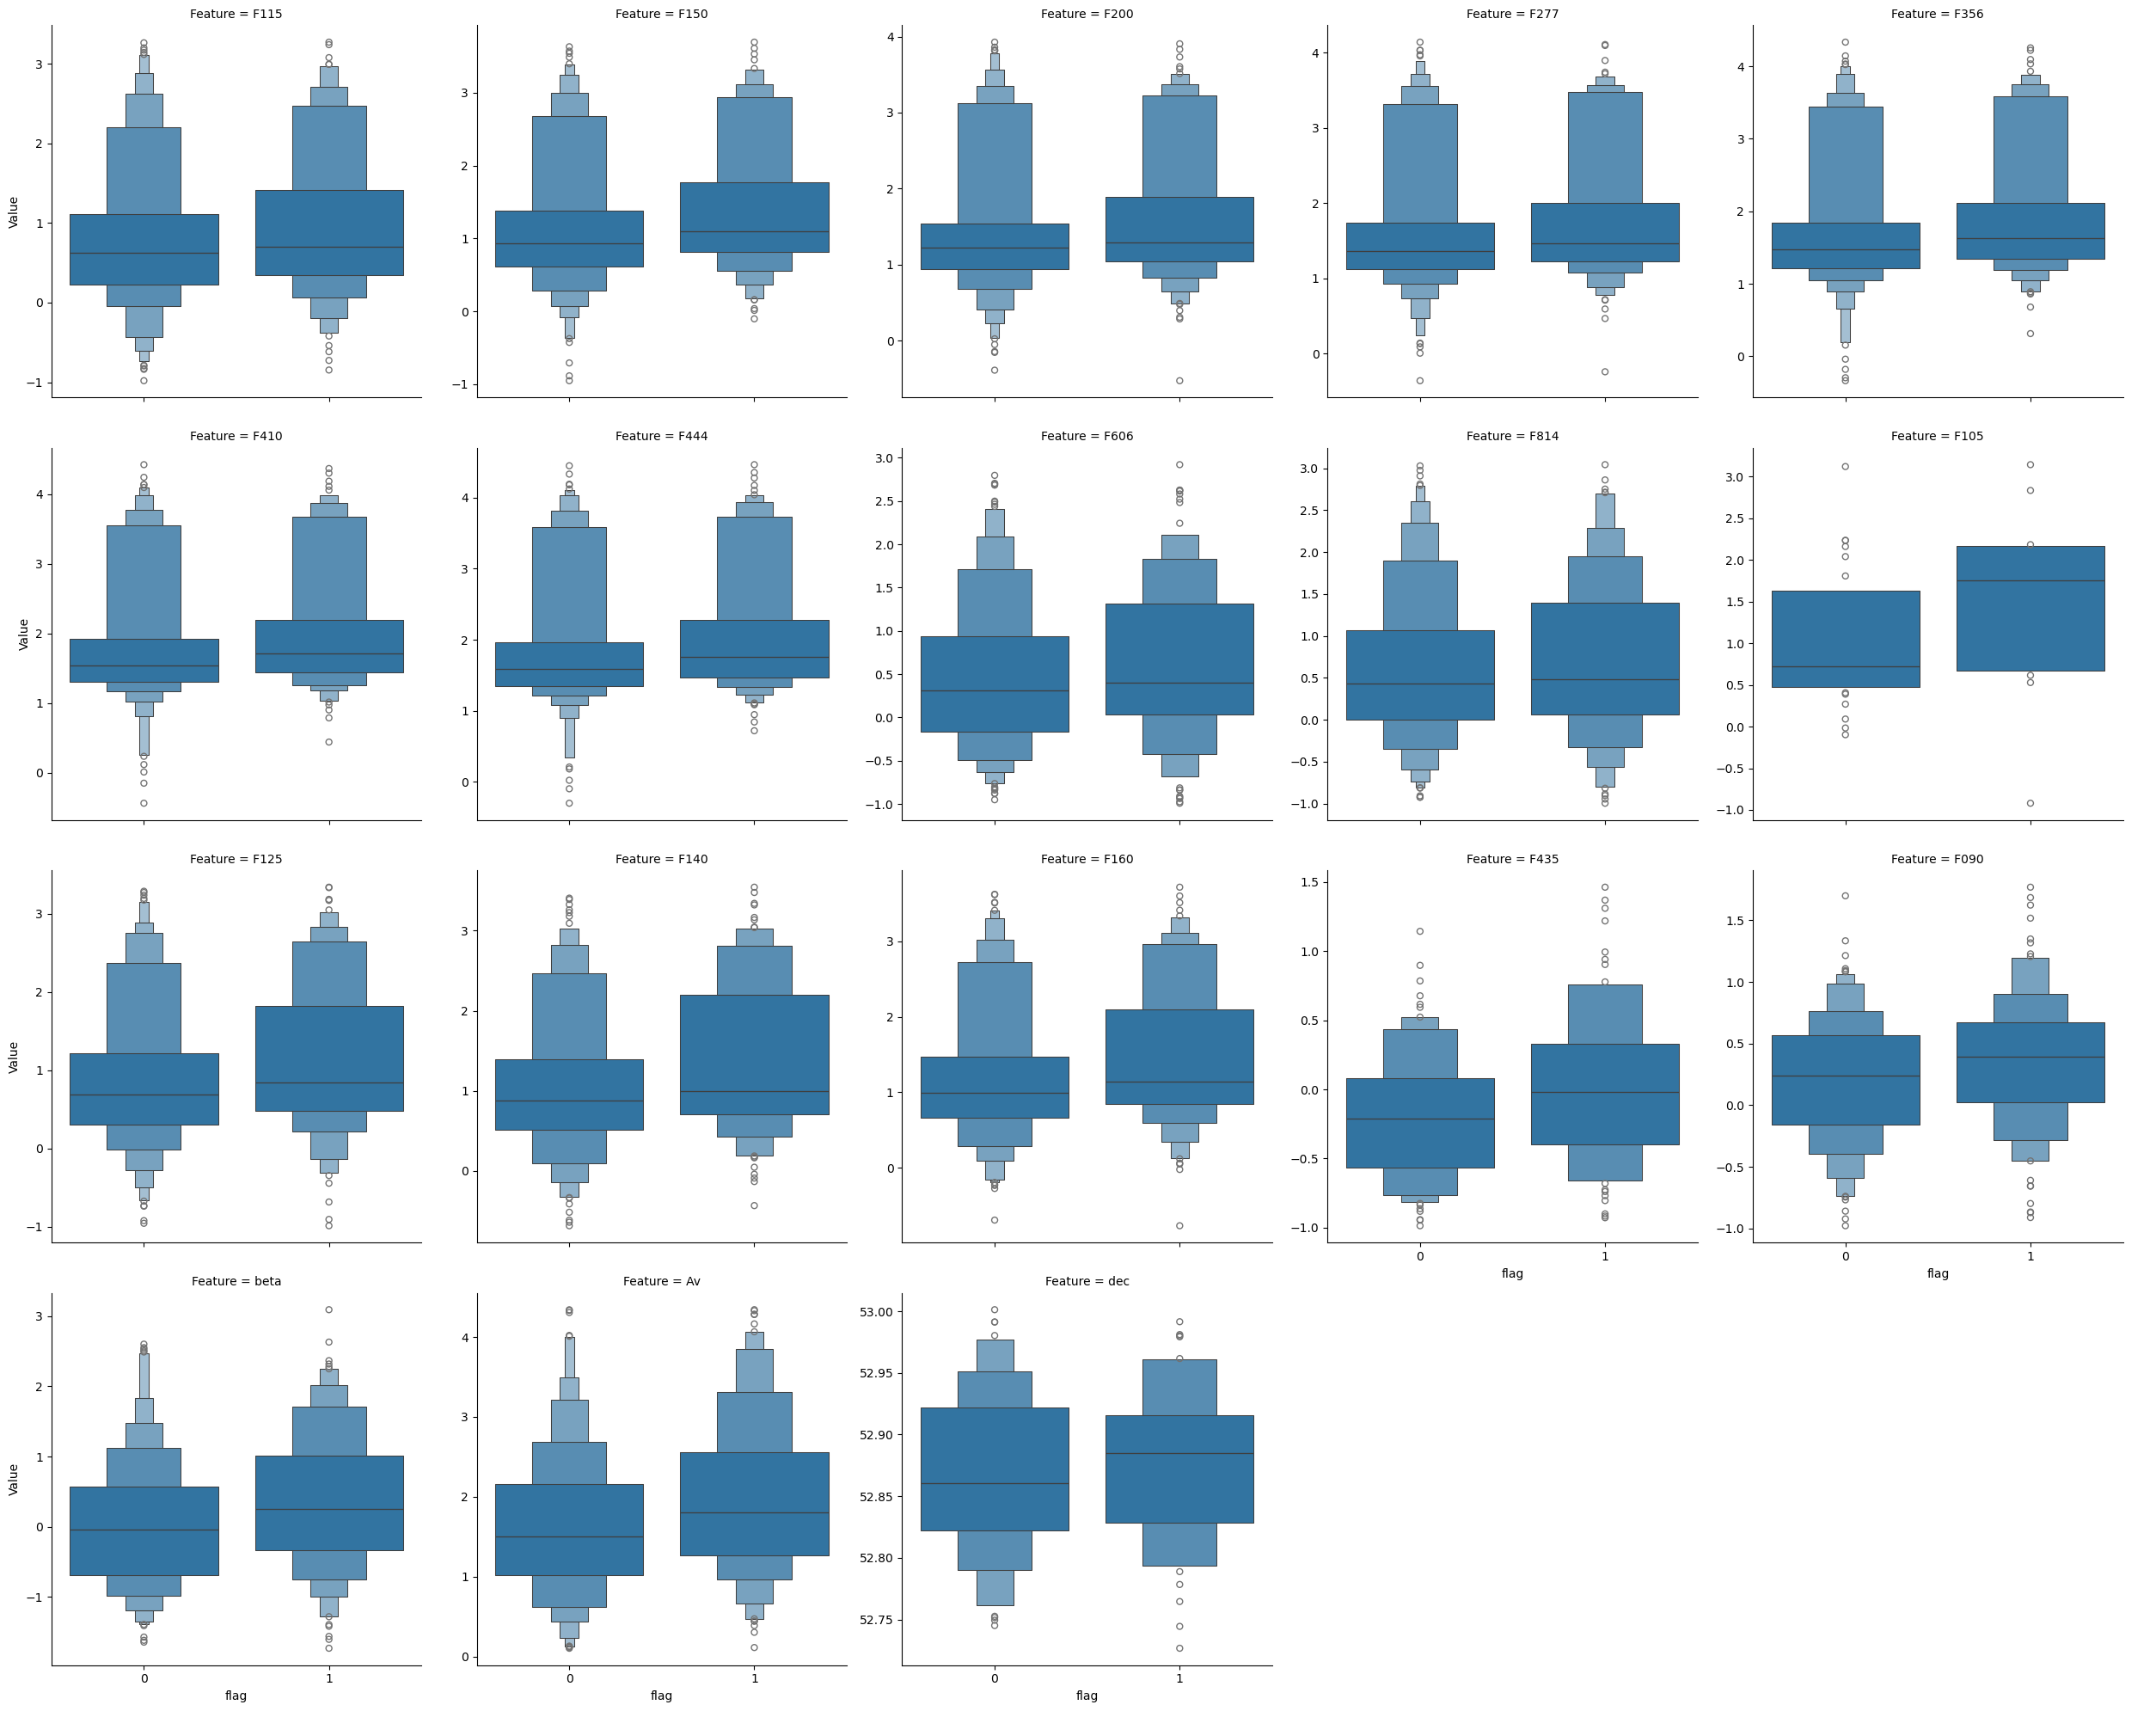

In [8]:
# melt -  basically expands df to each value of each in feature row has its own column
df_melted = pd.melt(df, id_vars=[out_feature], value_vars=in_features,
                    var_name='Feature', value_name='Value')

# plot them in the sad whsker way
g = sns.catplot(data=df_melted, x=out_feature, 
                y='Value', col='Feature', 
                kind='boxen', sharey=False, 
                col_wrap=5)

plt.show()

In [9]:
# helper function to plot a model
from pathlib import Path
def plot_loss(path, model, name=None):
    if name is None:
        name = Path(path).stem
    # load saved model
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=False)

    # get losses and model from file
    model.load_state_dict(checkpoint['model_state_dict'])
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']

    model.eval()

    # plot training and validation loss
    plt.figure(figsize=(12, 8))
    plt.plot(train_losses, label="Train Loss", marker='o')
    plt.plot(val_losses, label="Val Loss", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("RMSE Loss")
    plt.title(name)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


In [10]:
hist = False    
if hist:
    import matplotlib.pyplot as plt
    import numpy as np
    import torch
    from torch.utils.data import DataLoader

    model.eval()
    all_preds = [] # model outputs
    all_trues = [] # ground truths

    # set up batches for entire validation set
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=N_WORKERS)

    # predictions for entire validation set
    with torch.no_grad():
        for imgs, labels in val_loader:
            with torch.amp.autocast(DEVICE.type):
                outputs = model(imgs)
            all_preds.append(outputs.cpu().float().numpy())
            all_trues.append(labels.cpu().float().numpy())

    preds_matrix = np.vstack(all_preds)
    trues_matrix = np.vstack(all_trues)

    # get prediction residuals for each galaxy, then compute mean and stdev
    residuals = preds_matrix - trues_matrix 
    flattened_residuals = residuals.flatten()
    mean_val = np.mean(flattened_residuals)
    std_val = np.std(flattened_residuals)

    # plot histogram of residuals
    plt.figure()
    plt.hist(flattened_residuals, bins='fd', range=(-0.5, 0.5), color="blue")

    plt.title("Error Distribution")
    plt.xlabel("Residual Value")
    plt.ylabel("N")

    # show mean and std
    plt.text(0.25, plt.gca().get_ylim()[1] * 0.85, f"Mean: {mean_val:+.4f}", color="green")
    plt.text(0.25, plt.gca().get_ylim()[1] * 0.75, f"Std: {std_val:.4f}", color="orange")

    plt.tight_layout()
    plt.show()